In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [33]:
# linea inicial load_data = pd.read_csv('steam-200k.csv')
# Tuve que corregir y  la linea de codigo para cargar el dataset, e indicarle a pandas que no tiene encabezado, por ello agregue el parametro header=None,
#y agregue nombres a las columnas para evitar perder uno de los registros.

#linea corregida:
load_data = pd.read_csv('steam-200k.csv', header=None, names=['user_id', 'game', 'behavior', 'value', 'other'])


In [34]:
#una copia del dataset para trabajar con ella y no modificar el original
steam_games = load_data.copy()


In [35]:
#imprimimos las dimensiones del dataset
print("Dimensiones del dataset:", steam_games.shape)

Dimensiones del dataset: (200000, 5)


In [36]:
#verificamos los tipos de variables:
print("\nTipos de variables:")
display(steam_games.dtypes)



Tipos de variables:


user_id       int64
game            str
behavior        str
value       float64
other         int64
dtype: object

In [37]:
print("\nCantidad de valores nulos por columna:")
print(steam_games.isnull().sum())


Cantidad de valores nulos por columna:
user_id     0
game        0
behavior    0
value       0
other       0
dtype: int64


In [38]:
#verificamos los registros duplicados
print("\nCantidad de registros duplicados:", steam_games.duplicated().sum())


Cantidad de registros duplicados: 707


In [39]:
#Estadisticos descriptivos de las variables numéricas
print("\nEstadísticos descriptivos de las variables numéricas:")
print(steam_games.describe())


Estadísticos descriptivos de las variables numéricas:
            user_id          value     other
count  2.000000e+05  200000.000000  200000.0
mean   1.036559e+08      17.874384       0.0
std    7.208074e+07     138.056952       0.0
min    5.250000e+03       0.100000       0.0
25%    4.738420e+07       1.000000       0.0
50%    8.691201e+07       1.000000       0.0
75%    1.542309e+08       1.300000       0.0
max    3.099031e+08   11754.000000       0.0


In [40]:
# de la columna behavior, separamos  purchase y play para poder analizar la cantidad de horas jugadas y la cantidad de compras realizadas por cada usuario.
purchase_data = steam_games[steam_games['behavior'] == 'purchase']
play_data = steam_games[steam_games['behavior'] == 'play']

In [41]:
purchase_data = purchase_data.drop_duplicates()
play_data = play_data.drop_duplicates()

In [42]:
print(steam_games.head())

     user_id                        game  behavior  value  other
0  151603712  The Elder Scrolls V Skyrim  purchase    1.0      0
1  151603712  The Elder Scrolls V Skyrim      play  273.0      0
2  151603712                   Fallout 4  purchase    1.0      0
3  151603712                   Fallout 4      play   87.0      0
4  151603712                       Spore  purchase    1.0      0


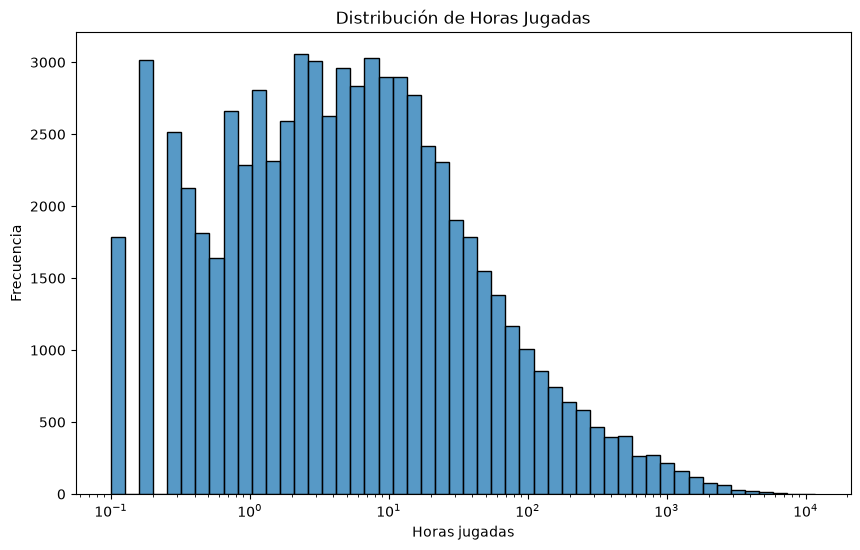

In [43]:
#visualizaciones para comprender la informacion del dataset 
plt.figure(figsize=(10, 6))
sns.histplot(data=play_data, x='value', bins=50, log_scale=True)
plt.title('Distribución de Horas Jugadas')
plt.xlabel('Horas jugadas')
plt.ylabel('Frecuencia')
plt.show()
#usé la escala logaritmica para poder visualizar mejor la distribucion de los datos, ya que la mayoria de los usuarios juegan pocas horas y hay pocos usuarios que juegan muchas horas.
#esto tuve que investigarlo porque no entendía que pasaba con el grafico.


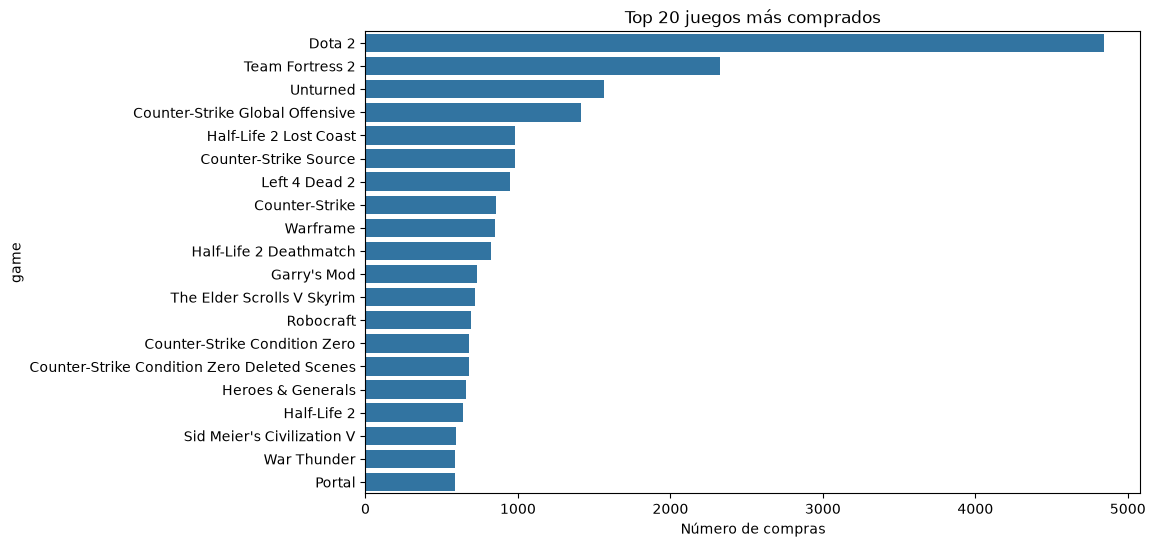

In [44]:
#grafico de juegos mas comprados
top_games = purchase_data['game'].value_counts().head(20) #Limitamos a los 20 juegos más comprados para que el gráfico sea más legible
plt.figure(figsize=(10, 6))
sns.barplot(x=top_games.values, y=top_games.index)
plt.title('Top 20 juegos más comprados')
plt.xlabel('Número de compras')
plt.show()

In [45]:
steam_games.to_csv('steam_games_cleaned.csv', index=False)  # Guardamos el dataset limpio en un nuevo archivo CSV

In [46]:
steam_games = steam_games.drop(['other'], axis=1)  # Eliminamos la columna 'other' ya que no es relevante para nuestro análisis

### A continuacion, se crearan variables para obtener información por usuario

In [47]:
#Verificamos cuantos juegos compro cada usuario
juegos_por_usuario = purchase_data.groupby('user_id')['game'].nunique().rename('juegos_comprados') #usamos nunique() para contar los juegos únicos comprados por cada usuario

print(juegos_por_usuario.describe())

count    12393.000000
mean        10.393287
std         35.635890
min          1.000000
25%          1.000000
50%          2.000000
75%          6.000000
max       1068.000000
Name: juegos_comprados, dtype: float64


In [48]:
#Obtenemos la cantidad de horas jugadas por cada usuario
horas_totales_usuario = play_data.groupby('user_id')['value'].sum().rename('horas_jugadas') #usamos sum() para obtener la cantidad total de horas jugadas por cada usuario

In [49]:
#Verificamos el numero de juegos jugados por cada usuario
n_juegos_jugados = play_data.groupby('user_id')['game'].count().rename('n_juegos_jugados') #usamos count() para obtener la cantidad de juegos jugados por cada usuario

In [50]:
#Obtenemos el promedio de horas jugadas por cada usuario
horas_promedio = play_data.groupby('user_id')['value'].mean().rename('horas_promedio')

In [51]:
#obtenemos la desviacion estandar de horas jugadas por cada usuario
horas_std = play_data.groupby('user_id')['value'].std().rename('horas_std')

In [52]:
#Creamos un dataframe con la informacion de cada usuario
usuarios_df = pd.concat([juegos_por_usuario, horas_totales_usuario, n_juegos_jugados, horas_promedio, horas_std], axis=1).reset_index()

In [53]:
#eliminamos los usuarios que no tienen compras ni horas jugadas, ya que no aportan informacion relevante para el analisis
usuarios_df = usuarios_df.fillna(0)  # Reemplazamos NaN con 0 para usuarios que no tienen compras ni horas jugadas

In [54]:
usuarios_df.head()

,user_id,juegos_comprados,horas_jugadas,n_juegos_jugados,horas_promedio,horas_std
0,5250,21,225.5,6.0,37.583333,57.121989
1,76767,36,1227.0,20.0,61.350000,104.713919
2,86540,82,255.0,15.0,17.000000,31.263900
3,103360,10,0.0,0.0,0.000000,0.000000
4,144736,8,0.1,1.0,0.100000,0.000000


Obtenemos el porcentaje de juegos jugados para separar a los jugadores activos y los acumuladores como yo que compran y nunca juegan nada.
Esto sería parte de la ingenieria de caracteristicas que aplicaría

In [55]:
usuarios_df = usuarios_df.set_index('user_id') # Establecemos el índice de la DataFrame en 'user_id' evitando que se convierta en una variable a escalar

In [56]:
#porcentaje de juegos  que realmente se jugaron
usuarios_df['pct_juegos_jugados'] = (usuarios_df['n_juegos_jugados'] / usuarios_df['juegos_comprados'])

In [57]:
#escalamos las variables numéricas para que tengan media 0 y desviación estándar 1, esto es importante para el análisis de clustering

usuarios_df['horas_jugadas_log'] = np.log1p(usuarios_df['horas_jugadas']) #usamos log1p para evitar problemas con los valores 0, ya que log(0) no está definido.
# Y así corregimos el sesgo de la variable horas_jugadas, ya que la mayoría de los usuarios juegan pocas horas y hay pocos usuarios que juegan muchas horas.

scaler = StandardScaler()
cols_a_escalar = ['juegos_comprados', 'horas_jugadas_log', 'n_juegos_jugados',
                   'horas_promedio', 'horas_std', 'pct_juegos_jugados']
usuarios_df[cols_a_escalar] = scaler.fit_transform(usuarios_df[cols_a_escalar])


### Modelado

Según mi investigación, recomendaría usar K-means para la segmentacion(clustering) debido al tamaño del dataset y que K-Means es mas rapido a diferencia del clustering jerarquico que es mas lento y pesado en la memoria y DBSCAN sufre mucho con bases de daatos grandes o con grupos de densidades distintas.

Tambien las variables  estan ya escaladas y tienen el formato para el que K-Means fue diseñado. En adición este metodo de clustering tambien es mas facil de intrepretar.

In [60]:
#k-means clustering

#Variales a usar
X = usuarios_df[cols_a_escalar]

inertias = []
silhouette_scores = []
rango_k = range(2, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))


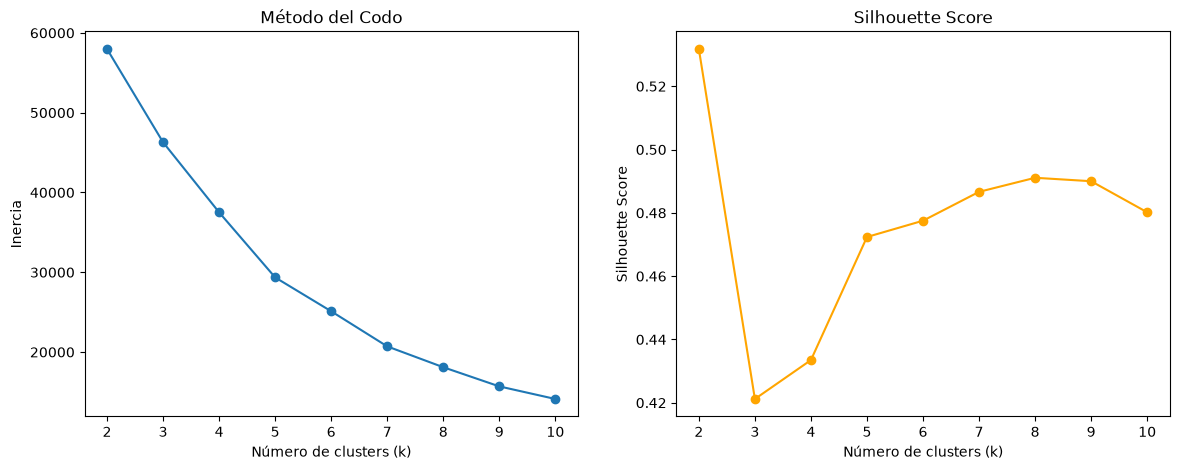

In [61]:
#graficamos el codo y el silhouette score para determinar el número óptimo de clusters
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(rango_k, inertias, marker='o')
ax[0].set_title('Método del Codo')
ax[0].set_xlabel('Número de clusters (k)')
ax[0].set_ylabel('Inercia')

ax[1].plot(rango_k, silhouette_scores, marker='o', color='orange')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Número de clusters (k)')
ax[1].set_ylabel('Silhouette Score')
plt.show()

In [65]:
k_optimo = 4
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
usuarios_df['cluster'] = kmeans_final.fit_predict(X)

print(usuarios_df['cluster'].value_counts())

cluster
0    6726
2    2896
3    2589
1     182
Name: count, dtype: int64


In [71]:
k_optimo = 5
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
usuarios_df['cluster'] = kmeans_final.fit_predict(X)

print(usuarios_df['cluster'].value_counts())

cluster
0    6243
1    3097
4    2723
2     182
3     148
Name: count, dtype: int64


In [67]:
# Cluster con k=4
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
usuarios_df['cluster_k4'] = kmeans_k4.fit_predict(X)

# Cluster con k=5
kmeans_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
usuarios_df['cluster_k5'] = kmeans_k5.fit_predict(X)

In [69]:
# Perfil completo para k=4
print("--- Perfiles k=4 ---")
print(usuarios_df.groupby('cluster_k4')[[
    'juegos_comprados', 'horas_jugadas', 'n_juegos_jugados',
    'horas_promedio', 'pct_juegos_jugados'
]].mean())

# Perfil completo para k=5
print("\n--- Perfiles k=5 ---")
print(usuarios_df.groupby('cluster_k5')[[
    'juegos_comprados', 'horas_jugadas', 'n_juegos_jugados',
    'horas_promedio', 'pct_juegos_jugados'
]].mean())

--- Perfiles k=4 ---
            juegos_comprados  horas_jugadas  n_juegos_jugados  horas_promedio  \
cluster_k4                                                                      
0                  -0.230878      31.124071         -0.221040       -0.194602   
1                   6.226753    2664.712088          6.246036       -0.171057   
2                  -0.147067      19.642472         -0.261198       -0.214796   
3                   0.326583    1040.619197          0.427332        0.757850   

            pct_juegos_jugados  
cluster_k4                      
0                     0.692496  
1                    -0.548881  
2                    -1.461901  
3                    -0.125211  

--- Perfiles k=5 ---
            juegos_comprados  horas_jugadas  n_juegos_jugados  horas_promedio  \
cluster_k5                                                                      
0                  -0.242883      20.337338         -0.239686       -0.209765   
1                   0.267969 

In [72]:
pd.set_option('display.max_columns', None)
print(usuarios_df.groupby('cluster_k5')[[
    'juegos_comprados', 'horas_jugadas', 'n_juegos_jugados',
    'horas_promedio', 'pct_juegos_jugados'
]].mean().to_string())

            juegos_comprados  horas_jugadas  n_juegos_jugados  horas_promedio  pct_juegos_jugados
cluster_k5                                                                                       
0                  -0.242883      20.337338         -0.239686       -0.209765            0.718815
1                   0.267969     737.729674          0.359876        0.403795           -0.099026
2                   6.226753    2664.712088          6.246036       -0.171057           -0.548881
3                  -0.077022    3471.864189         -0.079822        4.797041           -0.052674
4                  -0.159914      12.793794         -0.272912       -0.227623           -1.495846


In [73]:
## 2 dolores de cabeza y tres torcidas de ojos despues.

## K5 como el K optimo elegido.

En principio habia elegido el K4, sin embargo, por pura curiosidad decidi mirar el K5,  que me arrojaba un grupo mas pequeño que compra pocos juegos pero dedica muchas horas a ellos. Es un grupo interesante al que se puede aplicar promociones y estrategias de marketing para continuar fidelizandolo, ya que de por sí, es un usuario bastante fiel

### Cluster 0 Jugadores casuales

 Es el cluster con la mayor cantidad de usuarios (6243) Compran pocos juegos y tambien juegan pocas horas, sin embargo, juegan la mayoria de juegos comprados, valga la redundancia.
 Compran con intención de jugar a diferencia de otros usuarios que compran y no usan sus juegos. Serían el usuario mas típico de la plataforma.

### Cluster 1 Jugadores moderados

Con 3097 usuarios, se ubican en un punto medio, no son jugadores casuales ni intensivos todos sus valores estan ligeramente por encima de 0.  No tienen patrones de acumulación marcado ni de dedicación extrema, pero son consistentes con sus compras y horas jugadas.

### Cluster 4 Compradores de rebajas

Tienen el porcentaje de juegos jugados mas bajos de los clusters y la cantidad de horas jugadas mas baja siendo de alrededor 12.8 horas, compran muchos juegos que casi nunca abren. Usualmente los compradores de rebajas en Steam.
Usuarios: 2723

### Cluster 2 Compradores compulsivos/coleccionistas

Uno de los grupos pequeños,  estos jugadores, obtienen y juegan una cantidad extrema de juegos. La cantidad de juegos comprados y jugados coinciden con los valores mas altos. Basicamente son compradores compulsivos, sin embargo, su tiempo total de juego en aproximado 2665 horas viene de los diferentes titulos jugados y no de alguno o algunos que juegen en profundidad.

### Cluster 3 Fanaticos de algun nicho

El grupo mas pequeño de todos, con el valor de horas promedio mas alto de los 5 clusters, tienen muchas horas jugadas en pocos o un unico titulo. Son los jugadores mas intensivos con 3472 horas totales y son el contraste directo de los compradores compulsivos, compran pocos juegos, no obstante, cuando encuentran "EL JUEGO" lo agotan por completo. Suelen ser los fanaticos de algun nicho de juegos, como Final Fantasy, Halo, Age of Empires, entre otros.


# <h2 style="color:#DB8135"> Recomendaciones para el negocio. </h2>

### Jugadores Casuales.

Para nuestros jugadores casuales que son el segmento mas grande recomendaría estrategias de marketing basadas en retencion y activacion, por ejemplo, en la estrategia de activación; dar un beneficio o descuento para motivar la compra. Y como metodos de retención adaptar ofertas y mensajes segun su historial de compras y gustos, tambien los ya conocidos programas de lealtad podrían funcionar bien. 

Las promociones recomendadas para este tipo de jugadores pueden ser descuentos en generos de ya jugados o paquetes tematicos. Estos jugadores tendrían una prioridad baja en campañas de fidelización ya que muestra un comportamiento "sano", requieren mas cuidado que una inversion activa.

### Jugadores moderados.

Este segmento tiene el mayor margen de crecimiento a perfiles como "Fanatico" o "Coleccionistas". Una estrategia de marketing para este grupo podrían ser recomendaciones basadas en su historial o acceso anticipado a secuelas o DLC de juegos ya que jugaron bien. Lo que tambien iría de la mano con el tipo de ofertas recomendadas (Ofertas por tiempo limitado en secuelas/DLC's de sus juegos favoritos) Su prioridad en campañas de fidelización sería media debido a su potencial crecimiento hacia los segmentos mencionados al inicio.

### Compradores de rebajas

El objetivos para ellos no es venderles más, sino que se vuelvan mas activos con lo que ya tienen aumentando el compromiso (engagement). Es decir, estrategias/promociones con incentivos ligeros, como logros, contenido gratis, algo que reduzca el remordimiento de compra y aumente el engagement real. Otros ejemplos de promociones serían recompensas en el juego por las primeras horas jugadas.

Su prioridad para para campañas de fidelizacion sería quizá, mas baja que para los jugadores casuales, necesitan más reactivación ya que es la categoria de jugadores con menor retorno de inversion a corto plazo y mayor riesgo de churn.

### Coleccionistas

Para ellos lo recomendado sería estrategias de acceso exclusivo, por ejemplo, acceso anticipado a lanzamientos, programas VIP, suelen ser candidatos ideales para pruebas beta y feedback de producto. Las promociones para este grupo no necesitan descuentos grandes ya que ellos suelen valorar la exclusividad, se podrían considerar, paquetes premium, ediciones de coleccionista y acceso anticipado como ya mencionamos antes. Son la maxima prioridad en campañas de fidelizacion debido a su alta tasa de gasto y engagement, representan ROI directo de cualquier inversion en campañas de fidelizacion.

### Fanaticos

Requieren de una estrategia de monetización dentro de su juego, a diferencia de los jugadores casuales no buscan más juegos sino más de "SU JUEGO", como bien pueden ser expansiones, skins (o contenido comestico) o los conocidos pases de temporada. Esto mismo representaria su estrategia de marketing asi como el tipo de promociones que pueden brindarseles. Aunque compran poco su prioridad en campañas de fidelizacion sería alta, por su compromiso a los juegos que aman y suelen ser quienes más dejan reseñas positivas y forman comunidades alrededor de sus juegos. 




## <h2 style="color:#DB8135">Información que podría mejorar la segmentación.</h2>

Datos o variables que nos ayudarían con la segmentación desde mi punto de vista serían las reseñas con lo que podríamos medir el nivel de satisfaccion ya que un usuario puede no jugar porque no le gustó su juego y no por falta de tiempo.

Datos demograficos y de plataforma, que ayudaria con el targeting real de marketing, y por último la fecha de compra y fecha de última sesión ya que no sabemos si un usuario es pasivo desde siempre o si dejó de jugar hace poco y esto cambiaria la estrategia, si se  busca una reactivación o es un usuario ya perdido.

Tambien podríamos segmentar por preferencias por ejemplo en el caso de los fanaticos podriamos ajustar las recomendaciones de un fanatico de los shooters y otro de los RPG.